# **Pós Graduação - Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes – Colocação em Funcionamento**

---

### **Sessão 2 — Colocação em Funcionamento**
#### **2.1 — Filtragem dos Dados**

> Neste notebook vamos explorar **técnicas de filtragem** aplicadas a **séries temporais**, um passo crucial antes do treino de modelos baseados em **Redes Neuronais Recorrentes** (RNNs), como as **LSTM**.  
>  
> Será demonstrado como diferentes abordagens de filtragem (e.g., *Média Móvel*, *Savitzky-Golay*, e *Filtros Passa-Baixo*) impactam o desempenho do modelo.

---
> *Prof. Sérgio D. Correia, Maio 2026 [2025/26, 2º Semestre]*

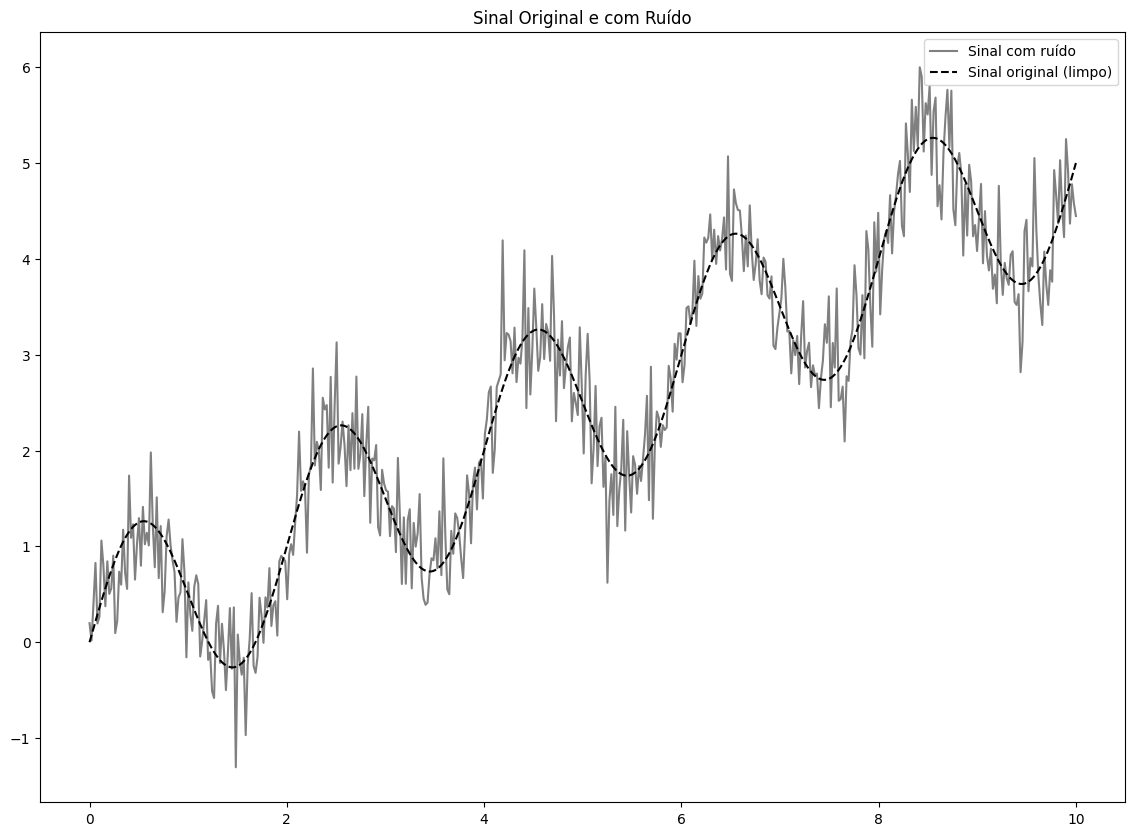

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy import stats
from scipy.fftpack import fft, ifft

# 1. Criar sinal com tendência + ruído
np.random.seed(42)
t = np.linspace(0, 10, 500)
sinal_limpo = np.sin(2 * np.pi * 0.5 * t) + 0.5 * t
ruido = np.random.normal(0, 0.4, size=t.shape)
sinal_ruidoso = sinal_limpo + ruido

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_ruidoso, label='Sinal com ruído', color='gray')
plt.plot(t, sinal_limpo, label='Sinal original (limpo)', color='black', linestyle='--')
plt.title("Sinal Original e com Ruído")
plt.legend()

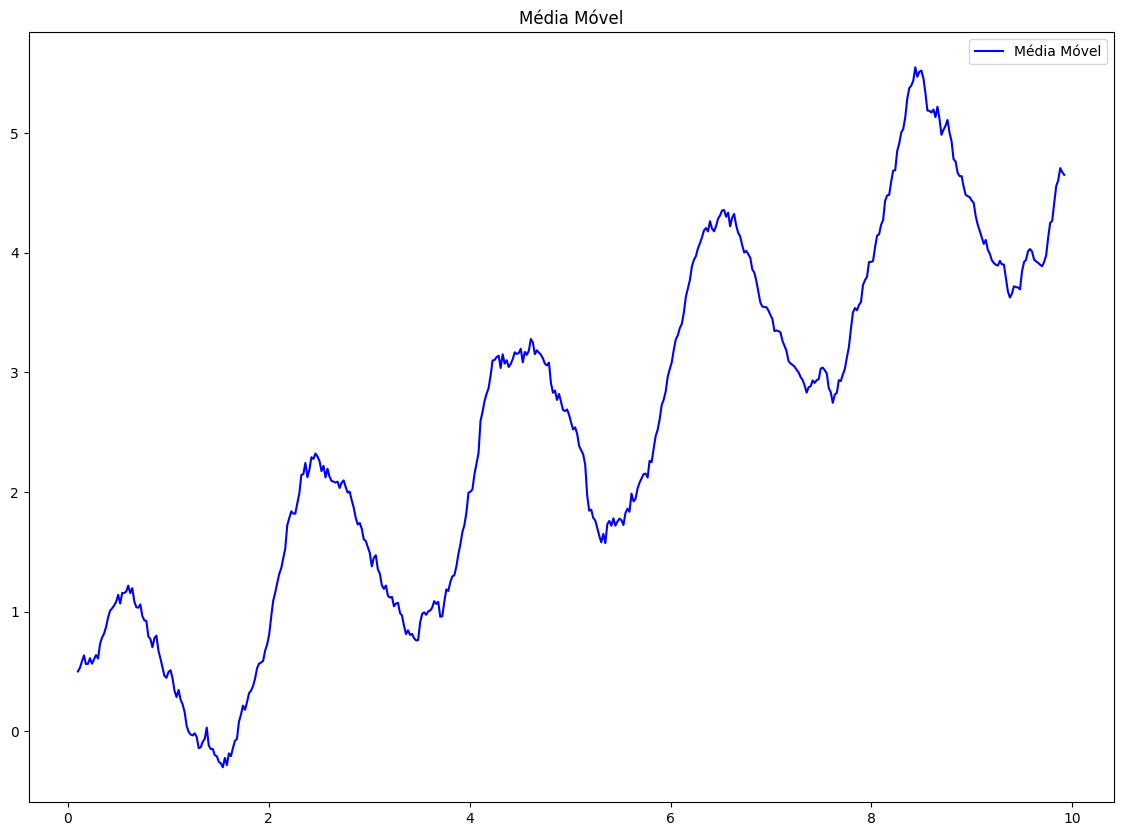

In [ ]:
# --- MÉTODO 1: Média Móvel ---
window_size = 10
sinal_movel = pd.Series(sinal_ruidoso).rolling(window=window_size, center=True).mean()

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_movel, label='Média Móvel', color='blue')
plt.title("Média Móvel")
plt.legend()

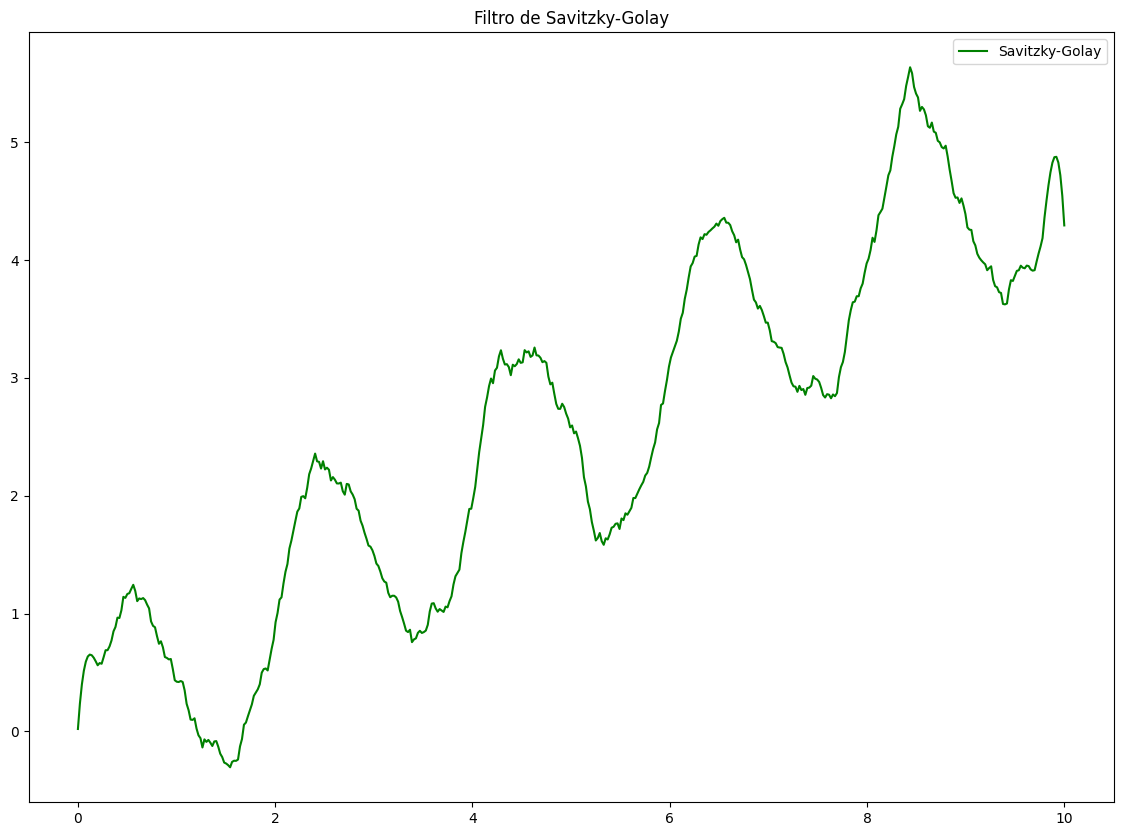

In [ ]:

# --- MÉTODO 2: Savitzky-Golay ---
sinal_savgol = savgol_filter(sinal_ruidoso, window_length=21, polyorder=3)

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_savgol, label='Savitzky-Golay', color='green')
plt.title("Filtro de Savitzky-Golay")
plt.legend()

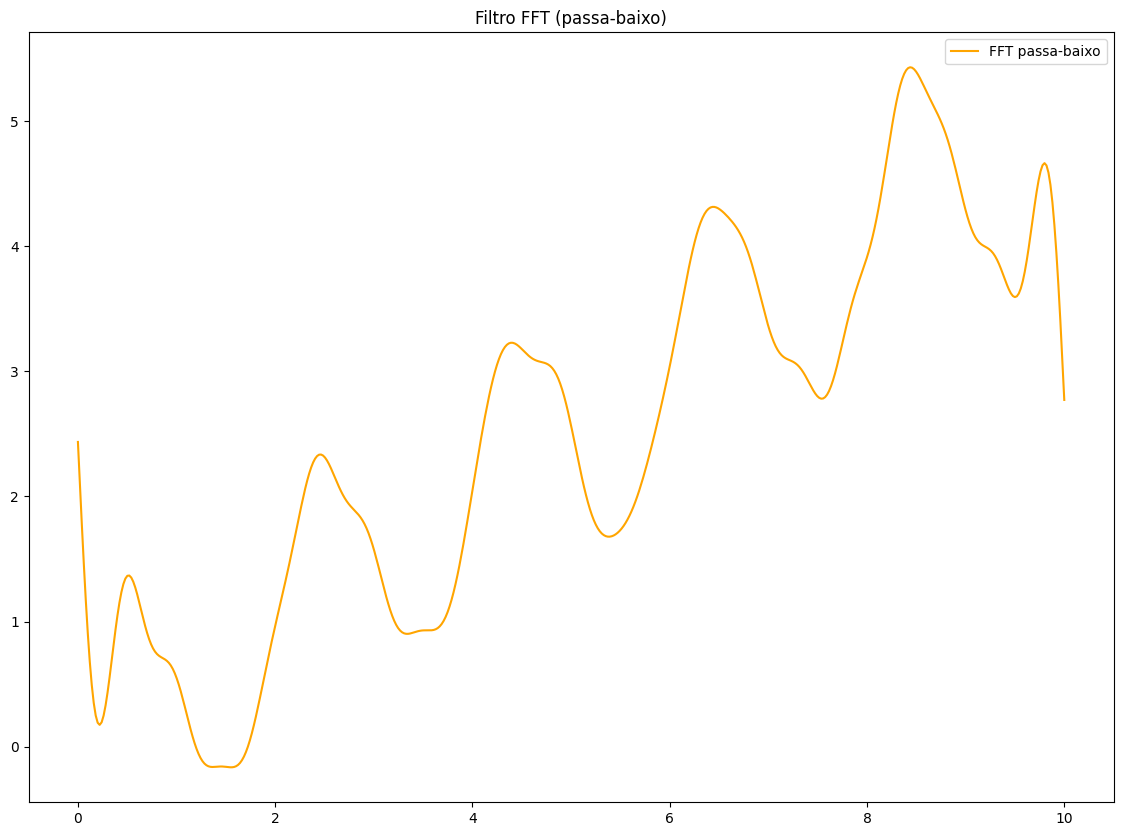

In [ ]:
# --- MÉTODO 3: Filtro Passa-Baixo (FFT) ---
fft_sinal = fft(sinal_ruidoso)
frequencias = np.fft.fftfreq(len(t), d=t[1] - t[0])
cutoff = 2  # Limite de frequência
fft_filtrado = fft_sinal.copy()
fft_filtrado[np.abs(frequencias) > cutoff] = 0
sinal_fft_filtrado = np.real(ifft(fft_filtrado))

# --- PLOTTING ---
plt.figure(figsize=(14, 10))

plt.plot(t, sinal_fft_filtrado, label='FFT passa-baixo', color='orange')
plt.title("Filtro FFT (passa-baixo)")
plt.legend()
